# SVM analysis of my pellichoopullu / Men Log (N vs NN)

This notebook turns my log into a small labeled dataset and trains an **SVM classifier** to predict **N vs NN** from the textual notes (plus a couple of structured fields).

**Label convention**
- `N`  = normal-ish / emotionally safer (nervous system grade)
- `NN` = not normal / misaligned / unsafe

> Close to 29, spoke to 30+ through texts that weren't logged and some couldn't even remember but faces and their bios I think.



Primary set - through parents
Rest -- 2025 field study of understanding male behaviour in pellichoopullu.

In [2]:
import re
import pandas as pd
import numpy as np

# --- Data (copied from your message) ---
rows = []

def add(group, code, name, age_diff, attraction, label, text):
    rows.append({
        "group": group,
        "code": code,
        "code_name": name,
        "age_diff_raw": age_diff,
        "attraction": attraction,
        "label": label,   # N / NN
        "text": text
    })

# Primary set 1–7
add("primary","1","The Angry My Way Highway Sherlyn Chopra Fan","+3 years","Goodlooking","NN",
    'Waiting for a line of girls in a queue; irritated, ego-driven, not sure about virginity.')
add("primary","2","The Nonchalant Smoker","+3 years","Goodlooking","NN",
    "Smoked; not a virgin; seemed nonchalant about marriage; likely had a girlfriend.")
add("primary","3","The Back-and-Forth Niceboy","+1 year","Goodlooking","N",
    "Sweet but confused; went back and forth; pressure to say yes; weird comments about his brother.")
add("primary","4","The Ghosting Moneyminded Yanker","+3 years","Not attracted","NN",
    "Ghosted; mother hounded your mom; physically active past; money-minded and incoherent.")
add("primary","5","The IIT Cornell Salsa “Escape Artist” Timewaster","+4 years","Not attracted","NN",
    "Led you on; used you as therapist; called himself a red flag; didn’t want kids; asked you to reject him.")
add("primary","6","The Ghosting Performing-Empathy Catfisher","+5 years","Found attractive","NN",
    "Offered help; ghosted twice; later found catfishing 18–33 year olds; age reduction and name-change on profile.")
add("primary","7","The Seemed Normal","Same age","Attracted","N",
    "Light, normal chat; aligned mostly but didn’t meet non-negotiable, so mutually disengaged.")

# Field experiment d1–d20
add("field","d1","The Secretive Chemist","+3–4 years","Not attracted","NN",
    "Prior physical past kept hidden; diverted questions; felt not ready; has trauma.")
add("field","d2","The Preaching Sleeparounder","+2–3 years","Not attracted","NN",
    "Religious preaching + opposite behaviour; manipulative; judgmental; hard to empathize with.")
add("field","d3","The Bestfriend is a Woman Man","+2 years","Not attracted","N",
    "Extrovert with close female friends; claimed no relationship; seemed decent but no vibe; horoscopes didn’t match.")
add("field","d4","The Nani Fan who Loves his Family in Percentages","Same age","Not attracted","NN",
    'Loves family "70%"; calls himself practical; cinematic; odd view of love; likely has trauma.')
add("field","d5","The Check Her Blind Spots Quizzler","Same age","Initially, then no","NN",
    "10-hour calls; revealed live-in past later; many divorce hypotheticals; insecure and manipulative.")
add("field","d6","The Godfather Fan","Same age","Attracted","NN",
    "Virgin but did other things; NRI; vegan; loved to cook; compliment-bombed; nice but different mindset.")
add("field","d7","The Sleeparound Preacher Liar (CMU)","+2–4 years","Not attracted","NN",
    "Slept around; lied; deflected with religious pravachan; felt like a very bad person.")
add("field","d8","The Spoke About his Ex Scientist","Same age","Not attracted","N",
    "Had a past relationship; reflected he should have had non-negotiables; no vibe.")
add("field","d9","The Stalking Plant Scientist","+4 years","Not attracted","NN",
    "Digitally stalked; tried to force a connection; knew people around you; felt unsafe and terrified.")
add("field","d10","The Objectifying Startup Founder","+4 years","Not attracted","NN",
    "Said men like women only for looks; recent broken engagement; needed healing; uncomfortable comments; you called him 'bro'.")
add("field","d11","The Gujju Marathi Honest Guy (Georgia Tech)","+1 year","Cute","N",
    "PhD; emotionally mature; openly admitted past; simple and normal.")
add("field","d12","The Awfully Poetic in Limerence Guy","Same age","Not attracted","NN",
    "Overly smitten; poetic spam; slightly insulting; used 'help' to stay in touch; blocked later.")
add("field","d13","The Misogynistic Objectifying Loser Punjabi Guy","+2–3 years","Not attracted","NN",
    "Asked for nude pictures; lied about past; stalked; extremely disrespectful and unsafe.")
add("field","d14","The Sent Me His Salary in the First Message Guy","+3–4 years","Cute","NN",
    "Led with salary; likely not a virgin; seemed maybe nice but you didn’t vibe at all.")
add("field","d15","The Mocking Projector “All Women Are Bad” Guy (Lingaith)","+4 years","Not attracted","NN",
    "Claimed everyone sleeps around; said women are evil; mocked your values; projected insecurity and misogyny.")
add("field","d16","The Pick Me, Insecure Guy","+4 years","Not attracted","NN",
    "Bragged that women wanted him; likely overcompensating; insecure and unappealing.")
add("field","d17","The Gujarati Younger Trifecta Guy","−2 years","Cute, some attraction","N",
    "Called you 'trifecta'; emotionally aligned ~80%; but rigid framework; insecurity; misaligned mindset and values on key areas (incl. animals).")
add("field","d18","The Younger Guy Who Wanted to Convince His Parents","−4 years","Goodlooking","N",
    "Too young; eats chicken; you couldn’t envision a future due to age gap and other factors.")
add("field","d19","The Don’t Care Much To Remember Guy","−1 year","Not attracted","N",
    "More of a hi–bye conversation; nothing memorable.")
add("field","d20","The “Not Many Are Virgins” Guy","+2–3 years","Not attracted","N",
    "Gujju guy; not a virgin; wished you well and gave a caveat; reasonably clear conversation.")

# Parent-only d21–d22 (kept as NN since it was a mismatch/unstable comms; edit if you want)
add("parent_only","d21","The “My Son is the Greatest, Would Love You as DIL” Auntie","Parent-only","Not Attracted","NN",
    "Spoke only to parent; son had just broken up; parent seemed blind to son’s actual state.")
add("parent_only","d22","The “Lovely Girl, Hope You Find a Job, My Son is an Atheist” Auntie","Parent-only","Not Attracted","NN",
    "Polite conversation; son did not get back; mismatch in values and communication.")

df = pd.DataFrame(rows)

def parse_age_diff(s: str) -> float:
    s = str(s).strip()
    if s.lower() in ["same age", "same"]:
        return 0.0
    if s.lower() in ["parent-only", "n/a"]:
        return np.nan
    s = s.replace("−","-")
    m = re.search(r'([+-]?\d+)\s*[–-]\s*(\d+)', s)
    if m:
        a = float(m.group(1))
        b = float(m.group(2))
        sign = -1.0 if a < 0 else 1.0
        return sign * (abs(a) + abs(b)) / 2.0
    m = re.search(r'([+-]?\d+)', s)
    if m:
        return float(m.group(1))
    return np.nan

df["age_diff_years"] = df["age_diff_raw"].map(parse_age_diff)
df["y"] = (df["label"] == "NN").astype(int)  # 1=NN, 0=N

df


,group,code,code_name,age_diff_raw,attraction,label,text,age_diff_years,y
0,primary,1,The Angry My Way Highway Sherlyn Chopra Fan,+3 years,Goodlooking,NN,Waiting for a line of girls in a queue; irrita...,3.0,1
1,primary,2,The Nonchalant Smoker,+3 years,Goodlooking,NN,Smoked; not a virgin; seemed nonchalant about ...,3.0,1
2,primary,3,The Back-and-Forth Niceboy,+1 year,Goodlooking,N,Sweet but confused; went back and forth; press...,1.0,0
3,primary,4,The Ghosting Moneyminded Yanker,+3 years,Not attracted,NN,Ghosted; mother hounded your mom; physically a...,3.0,1
4,primary,5,The IIT Cornell Salsa “Escape Artist” Timewaster,+4 years,Not attracted,NN,Led you on; used you as therapist; called hims...,4.0,1
5,primary,6,The Ghosting Performing-Empathy Catfisher,+5 years,Found attractive,NN,Offered help; ghosted twice; later found catfi...,5.0,1
6,primary,7,The Seemed Normal,Same age,Attracted,N,"Light, normal chat; aligned mostly but didn’t ...",0.0,0
7,field,d1,The Secretive Chemist,+3–4 years,Not attracted,NN,Prior physical past kept hidden; diverted ques...,3.5,1
8,field,d2,The Preaching Sleeparounder,+2–3 years,Not attracted,NN,Religious preaching + opposite behaviour; mani...,2.5,1
9,field,d3,The Bestfriend is a Woman Man,+2 years,Not attracted,N,Extrovert with close female friends; claimed n...,2.0,0


## Quick dataset sanity checks

In [ ]:
df[["label","group"]].value_counts()


,,count
label,group,
NN,field,13
N,field,7
NN,primary,5
N,primary,2
NN,parent_only,2


In [ ]:
df.isna().sum()


## Basic exploratory analysis

This is not “scientific”; it just helps you see patterns in **age gap**, **attraction**, and **label** distribution.


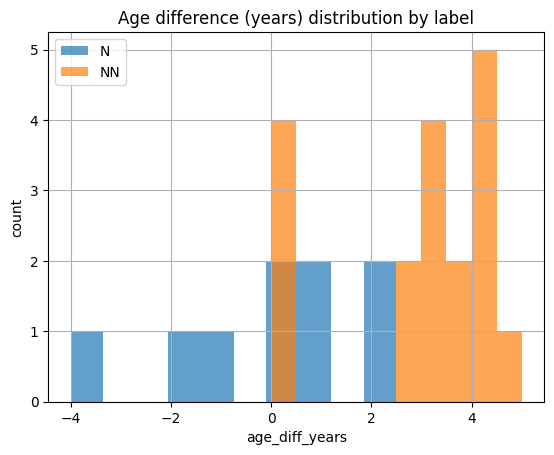

In [ ]:
import matplotlib.pyplot as plt

# Age difference distribution by label (ignoring NaNs)
tmp = df.dropna(subset=["age_diff_years"])

plt.figure()
tmp[tmp["label"]=="N"]["age_diff_years"].hist(alpha=0.7, bins=10)
tmp[tmp["label"]=="NN"]["age_diff_years"].hist(alpha=0.7, bins=10)
plt.title("Age difference (years) distribution by label")
plt.xlabel("age_diff_years")
plt.ylabel("count")
plt.legend(["N","NN"])
plt.show()


In [ ]:
# Attraction vs label counts
pd.crosstab(df["attraction"], df["label"]).sort_index()


label,N,NN
attraction,,
Attracted,1,1
Cute,1,1
"Cute, some attraction",1,0
Found attractive,0,1
Goodlooking,2,2
"Initially, then no",0,1
N/A,0,2
Not attracted,4,12


## Train an SVM classifier

We’ll build a pipeline:
- **Text features**: TF-IDF on `text`
- **Optional structured features**: one-hot for `attraction` + numeric `age_diff_years` (imputed)

Classifier options:
- `LinearSVC` (linear SVM) — good for text
- You can swap to `SVC(kernel="rbf")` later if you want nonlinear

Because the dataset is small, we’ll use **stratified cross-validation**.


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import LinearSVC
from sklearn.preprocessing import FunctionTransformer

X = df[["text","attraction","age_diff_years"]].copy()
y = df["y"].copy()

# Column-wise preprocessing
text_features = "text"
cat_features = ["attraction"]
num_features = ["age_diff_years"]

preprocess = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(ngram_range=(1,2), min_df=1), text_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]), num_features)
    ],
    remainder="drop"
)

clf = LinearSVC(class_weight="balanced", random_state=42)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", clf)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(pipe, X, y, cv=cv, scoring="f1")
scores, scores.mean(), scores.std()


(array([0.66666667, 0.88888889, 0.88888889, 1.        , 0.33333333]),
 np.float64(0.7555555555555555),
 np.float64(0.2372684056006958))

              precision    recall  f1-score   support

           N       0.50      0.44      0.47         9
          NN       0.76      0.80      0.78        20

    accuracy                           0.69        29
   macro avg       0.63      0.62      0.63        29
weighted avg       0.68      0.69      0.68        29



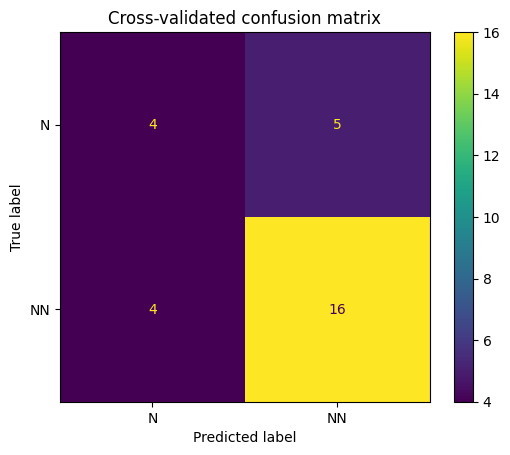

In [ ]:
# Cross-validated predictions for a confusion matrix + report
y_pred = cross_val_predict(pipe, X, y, cv=cv)

print(classification_report(y, y_pred, target_names=["N","NN"]))

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["N","NN"])
disp.plot()
plt.title("Cross-validated confusion matrix")
plt.show()


## What words push the SVM toward NN vs N?

For a **linear** SVM, we can inspect the learned weights after fitting on all data.
This gives you a “what language correlates with NN” list (again: exploratory).


In [ ]:
# Fit on all data to inspect feature weights
pipe.fit(X, y)

# Get feature names
# ColumnTransformer + vectorizer: need to stitch names together
tfidf = pipe.named_steps["preprocess"].named_transformers_["text"]
ohe = pipe.named_steps["preprocess"].named_transformers_["cat"]

tfidf_names = tfidf.get_feature_names_out()
ohe_names = ohe.get_feature_names_out(cat_features)
num_names = np.array(num_features)

feature_names = np.concatenate([tfidf_names, ohe_names, num_names])

coefs = pipe.named_steps["clf"].coef_.ravel()  # binary

top_pos_idx = np.argsort(coefs)[-25:][::-1]   # toward NN (y=1)
top_neg_idx = np.argsort(coefs)[:25]          # toward N (y=0)

top_NN = pd.DataFrame({"feature": feature_names[top_pos_idx], "weight": coefs[top_pos_idx]})
top_N  = pd.DataFrame({"feature": feature_names[top_neg_idx], "weight": coefs[top_neg_idx]})

top_NN, top_N


(                          feature    weight
 0   attraction_Initially, then no  0.409923
 1                  age_diff_years  0.323835
 2                              in  0.229785
 3                          likely  0.210310
 4                           calls  0.210106
 5                  attraction_N/A  0.192482
 6                           later  0.191475
 7                            nice  0.163773
 8                        nice but  0.163773
 9                              70  0.152340
 10                      family 70  0.152340
 11                        view of  0.152340
 12                     likely has  0.152340
 13                       70 calls  0.152340
 14                  cinematic odd  0.152340
 15                      cinematic  0.152340
 16                  calls himself  0.152340
 17                           love  0.152340
 18                       odd view  0.152340
 19            practical cinematic  0.152340
 20                      practical  0.152340
 21       

## Score each person (probability-ish)

`LinearSVC` doesn’t output calibrated probabilities by default, but we can still compute a **decision score**.
Higher score ⇒ model leaning “NN”.

You can use this as a *ranking tool* to see which entries are most strongly NN-coded by the notes.


In [ ]:
# Decision function scores
scores = pipe.decision_function(X)
out = df[["group","code","code_name","label","text"]].copy()
out["svm_score_NN"] = scores
out.sort_values("svm_score_NN", ascending=False).head(15)


,group,code,code_name,label,text,svm_score_NN
5,primary,6,The Ghosting Performing-Empathy Catfisher,NN,Offered help; ghosted twice; later found catfi...,1.504644
22,field,d16,"The Pick Me, Insecure Guy",NN,Bragged that women wanted him; likely overcomp...,1.028359
15,field,d9,The Stalking Plant Scientist,NN,Digitally stalked; tried to force a connection...,0.998405
4,primary,5,The IIT Cornell Salsa “Escape Artist” Timewaster,NN,Led you on; used you as therapist; called hims...,0.990846
16,field,d10,The Objectifying Startup Founder,NN,Said men like women only for looks; recent bro...,0.985040
21,field,d15,The Mocking Projector “All Women Are Bad” Guy ...,NN,Claimed everyone sleeps around; said women are...,0.977082
7,field,d1,The Secretive Chemist,NN,Prior physical past kept hidden; diverted ques...,0.953713
27,parent_only,d21,"The “My Son is the Greatest, Would Love You as...",NN,Spoke only to parent; son had just broken up; ...,0.944105
28,parent_only,d22,"The “Lovely Girl, Hope You Find a Job, My Son ...",NN,Polite conversation; son did not get back; mis...,0.923136
13,field,d7,The Sleeparound Preacher Liar (CMU),NN,Slept around; lied; deflected with religious p...,0.865000


## Probability of finding the one---- ?!
1. Age
2. How long a person's been away from family?
3. Past relationships and how DEEP it was
4. Value Alignment
5. Phase Alignment
6. Physical attractiveness
7. How does he treat his family?
9. Past? Closure? Healing? None?
10. Height
11. Hobbies
12. Coherence and maturity
13. EQ and IQ
14. Shouldn't look better than his personality
15. Non-negs


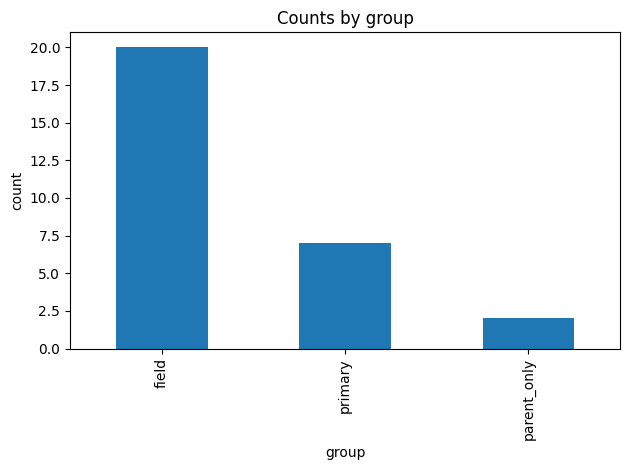

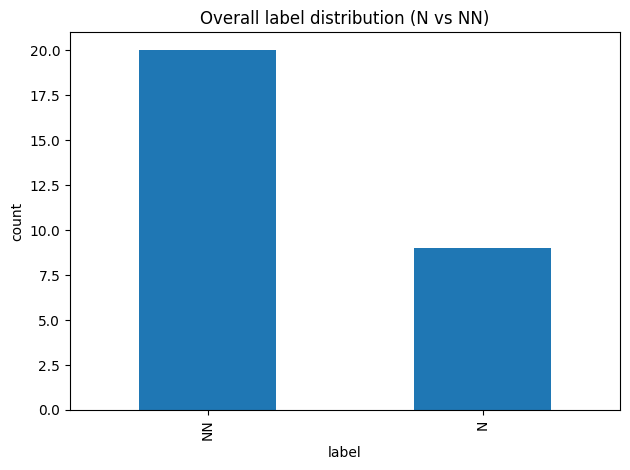

<Figure size 640x480 with 0 Axes>

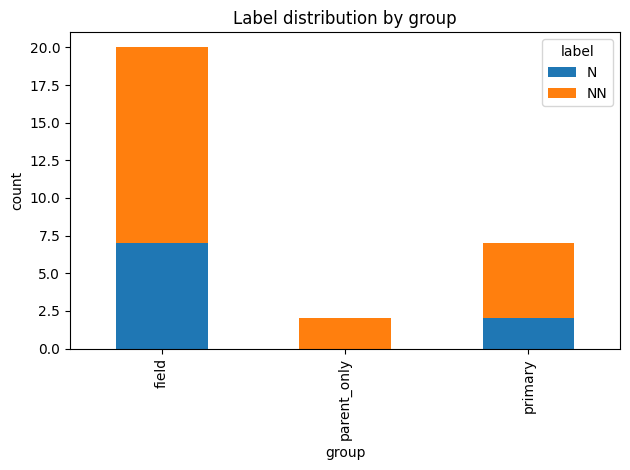

<Figure size 800x400 with 0 Axes>

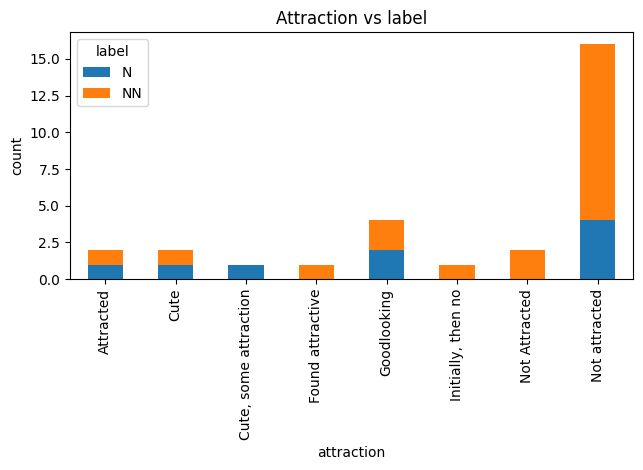

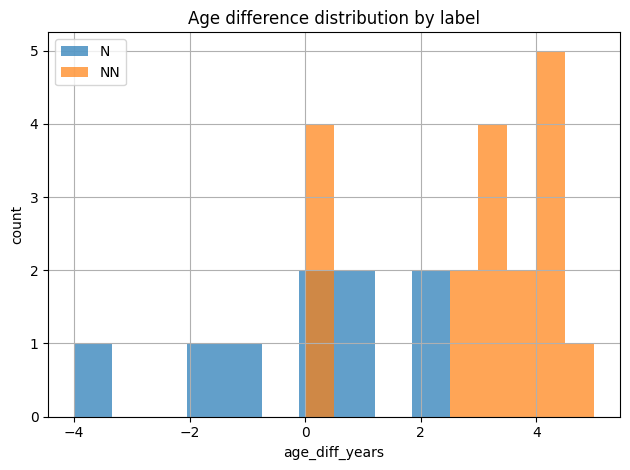

<Figure size 640x480 with 0 Axes>

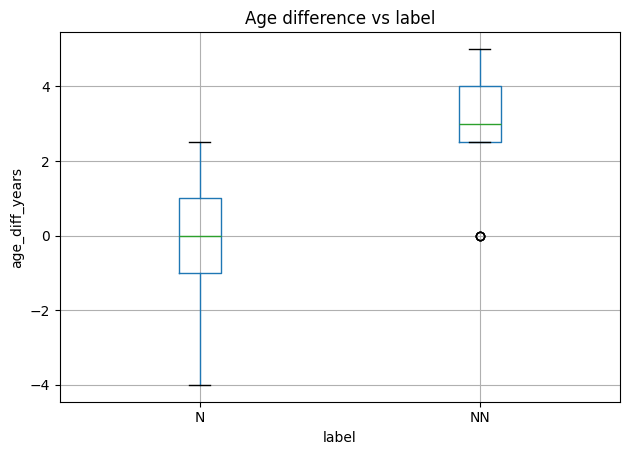

<Figure size 640x480 with 0 Axes>

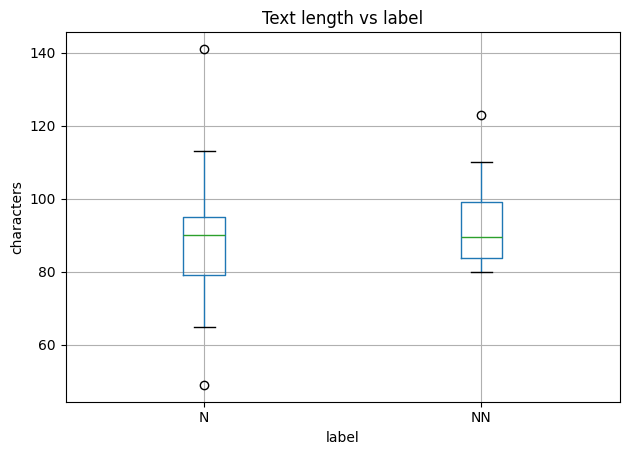

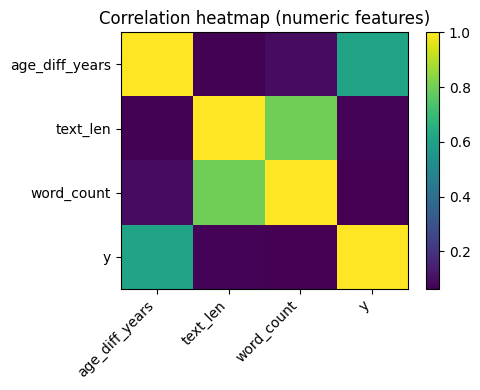

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Derived features (for EDA)
df["text_len"] = df["text"].astype(str).str.len()
df["word_count"] = df["text"].astype(str).str.split().map(len)

# 1) Counts by group
plt.figure()
df["group"].value_counts().plot(kind="bar")
plt.title("Counts by group")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# 2) Overall label distribution
plt.figure()
df["label"].value_counts().plot(kind="bar")
plt.title("Overall label distribution (N vs NN)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# 3) Label distribution by group (stacked bar)
ct = pd.crosstab(df["group"], df["label"])
plt.figure()
ct.plot(kind="bar", stacked=True)
plt.title("Label distribution by group")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# 4) Attraction vs label (stacked bar)
ct2 = pd.crosstab(df["attraction"], df["label"]).sort_index()
plt.figure(figsize=(8,4))
ct2.plot(kind="bar", stacked=True)
plt.title("Attraction vs label")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# 5) Age difference histogram by label
tmp = df.dropna(subset=["age_diff_years"])
plt.figure()
tmp[tmp["label"]=="N"]["age_diff_years"].hist(alpha=0.7, bins=10)
tmp[tmp["label"]=="NN"]["age_diff_years"].hist(alpha=0.7, bins=10)
plt.title("Age difference distribution by label")
plt.xlabel("age_diff_years")
plt.ylabel("count")
plt.legend(["N","NN"])
plt.tight_layout()
plt.show()

# 6) Age difference boxplot by label
plt.figure()
df.boxplot(column="age_diff_years", by="label")
plt.title("Age difference vs label")
plt.suptitle("")
plt.ylabel("age_diff_years")
plt.tight_layout()
plt.show()

# 7) Text length boxplot by label
plt.figure()
df.boxplot(column="text_len", by="label")
plt.title("Text length vs label")
plt.suptitle("")
plt.ylabel("characters")
plt.tight_layout()
plt.show()

# 8) Correlation heatmap (numeric features)
num = df[["age_diff_years","text_len","word_count","y"]].copy()
corr = num.corr(numeric_only=True).values
cols = num.columns.tolist()

plt.figure(figsize=(5,4))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(cols)), cols, rotation=45, ha="right")
plt.yticks(range(len(cols)), cols)
plt.title("Correlation heatmap (numeric features)")
plt.colorbar()
plt.tight_layout()
plt.show()


In [ ]:
# Define what counts as "attracted"
attracted_mask = df["attraction"].str.contains(
    "Attracted|Goodlooking|Cute|some attraction|Found attractive",
    case=False,
    na=False
)

df_attracted_normal = df[
    (df["label"] == "N") &
    (attracted_mask)
].copy()

df_attracted_normal[["group","code","code_name","age_diff_years","attraction"]]


,group,code,code_name,age_diff_years,attraction
2,primary,3,The Back-and-Forth Niceboy,1.0,Goodlooking
6,primary,7,The Seemed Normal,0.0,Attracted
9,field,d3,The Bestfriend is a Woman Man,2.0,Not attracted
14,field,d8,The Spoke About his Ex Scientist,0.0,Not attracted
17,field,d11,The Gujju Marathi Honest Guy (Georgia Tech),1.0,Cute
23,field,d17,The Gujarati Younger Trifecta Guy,-2.0,"Cute, some attraction"
24,field,d18,The Younger Guy Who Wanted to Convince His Par...,-4.0,Goodlooking
25,field,d19,The Don’t Care Much To Remember Guy,-1.0,Not attracted
26,field,d20,The “Not Many Are Virgins” Guy,2.5,Not attracted


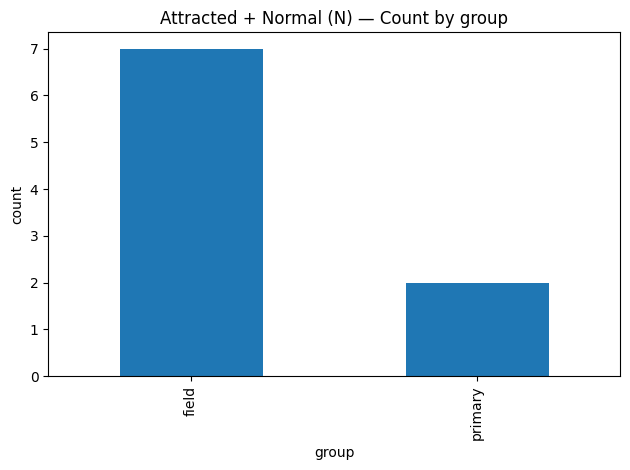

In [ ]:
plt.figure()
df_attracted_normal["group"].value_counts().plot(kind="bar")
plt.title("Attracted + Normal (N) — Count by group")
plt.ylabel("count")
plt.tight_layout()
plt.show()


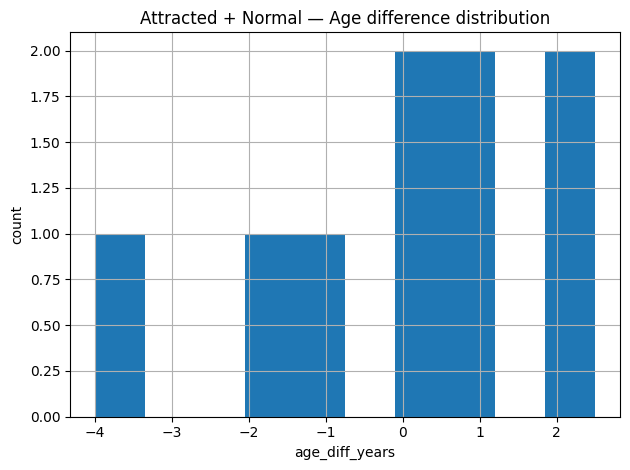

In [ ]:
plt.figure()
df_attracted_normal["age_diff_years"].hist(bins=10)
plt.title("Attracted + Normal — Age difference distribution")
plt.xlabel("age_diff_years")
plt.ylabel("count")
plt.tight_layout()
plt.show()


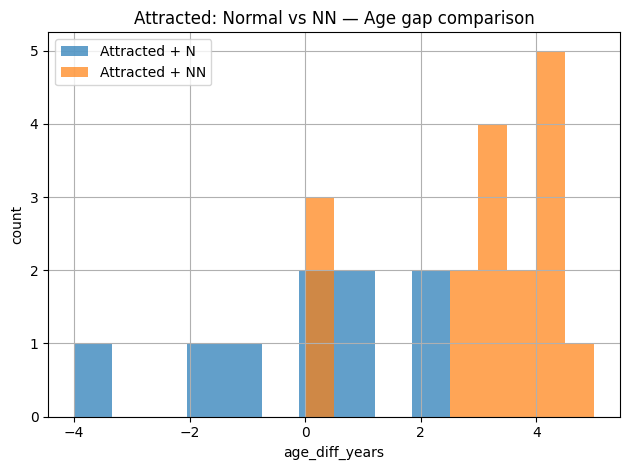

In [ ]:
df_attracted_nn = df[
    (df["label"] == "NN") &
    (attracted_mask)
].copy()

plt.figure()
df_attracted_normal["age_diff_years"].hist(alpha=0.7, bins=10)
df_attracted_nn["age_diff_years"].hist(alpha=0.7, bins=10)
plt.legend(["Attracted + N","Attracted + NN"])
plt.title("Attracted: Normal vs NN — Age gap comparison")
plt.xlabel("age_diff_years")
plt.ylabel("count")
plt.tight_layout()
plt.show()


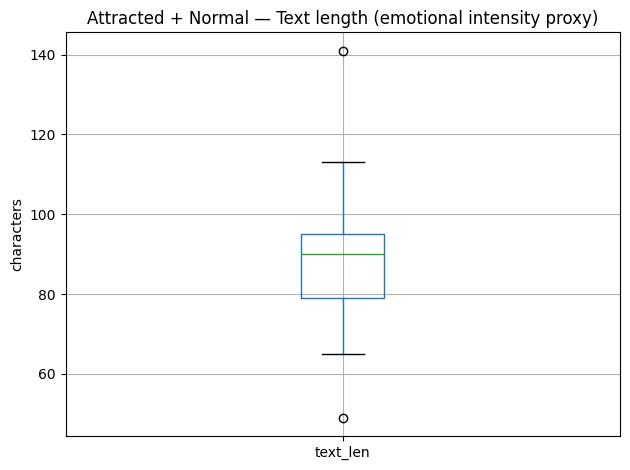

In [ ]:
# Ensure features exist
df["text_len"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

plt.figure()
df_attracted_normal.boxplot(column="text_len")
plt.title("Attracted + Normal — Text length (emotional intensity proxy)")
plt.ylabel("characters")
plt.tight_layout()
plt.show()


In [ ]:
df_attracted_normal[
    ["code","code_name","group","age_diff_years","attraction","text"]
]


,code,code_name,group,age_diff_years,attraction,text
2,3,The Back-and-Forth Niceboy,primary,1.0,Goodlooking,Sweet but confused; went back and forth; press...
6,7,The Seemed Normal,primary,0.0,Attracted,"Light, normal chat; aligned mostly but didn’t ..."
9,d3,The Bestfriend is a Woman Man,field,2.0,Not attracted,Extrovert with close female friends; claimed n...
14,d8,The Spoke About his Ex Scientist,field,0.0,Not attracted,Had a past relationship; reflected he should h...
17,d11,The Gujju Marathi Honest Guy (Georgia Tech),field,1.0,Cute,PhD; emotionally mature; openly admitted past;...
23,d17,The Gujarati Younger Trifecta Guy,field,-2.0,"Cute, some attraction",Called you 'trifecta'; emotionally aligned ~80...
24,d18,The Younger Guy Who Wanted to Convince His Par...,field,-4.0,Goodlooking,Too young; eats chicken; you couldn’t envision...
25,d19,The Don’t Care Much To Remember Guy,field,-1.0,Not attracted,More of a hi–bye conversation; nothing memorable.
26,d20,The “Not Many Are Virgins” Guy,field,2.5,Not attracted,Gujju guy; not a virgin; wished you well and g...


In [ ]:
# Filter PRIMARY set
df_primary = df[df["group"] == "primary"].copy()

# Define attraction (same rule you used elsewhere)
attracted_mask = df_primary["attraction"].str.contains(
    "Attracted|Goodlooking|Cute|Found attractive",
    case=False,
    na=False
)

# Define "the one" criteria
is_the_one = (
    (df_primary["label"] == "N") &
    (attracted_mask)
)

# Counts
total_primary = len(df_primary)
num_the_one = is_the_one.sum()

probability = num_the_one / total_primary

total_primary, num_the_one, probability


(7, np.int64(2), np.float64(0.2857142857142857))

total_primary = 7
num_the_one   = 2
probability   ≈ 0.2857

In [ ]:

from statsmodels.stats.proportion import proportion_confint

low, high = proportion_confint(
    count=num_the_one,
    nobs=total_primary,
    alpha=0.05,
    method="wilson"
)

low, high


(0.08221892400405661, 0.6410655481673807)

In [3]:
import re
import numpy as np
import pandas as pd

# --- df is assumed to already exist from your code ---
# df columns: group, code, code_name, age_diff_raw, attraction, label, text, age_diff_years

# ---------------------------
# 1) Build y = attraction label
# ---------------------------
def attraction_to_y(a: str) -> int:
    """
    Returns 1 if attraction indicates you found him attractive/goodlooking/cute (any level),
    else 0.
    Adjust rules freely.
    """
    a = str(a).strip().lower()

    positive_markers = [
        "attracted",
        "found attractive",
        "goodlooking",
        "cute",
        "initially"  # you wrote "Initially, then no" -> counts as some attraction signal
    ]
    negative_markers = [
        "not attracted",
        "no vibe"
    ]

    if any(m in a for m in negative_markers):
        return 0
    if any(m in a for m in positive_markers):
        return 1
    return 0  # default conservative

df = df.copy()
df["y_attr"] = df["attraction"].map(attraction_to_y).astype(int)

# Optional: drop parent-only rows if you feel they distort attraction learning
# (they’re not real “you met him” datapoints)
df_model = df[df["group"] != "parent_only"].copy()

# Basic sanity check
print("Rows:", len(df_model))
print(df_model["y_attr"].value_counts())

# ---------------------------
# 2) SVM pipeline (text + numeric + categorical)
# ---------------------------
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import LinearSVC

X = df_model[["text", "age_diff_years", "attraction"]]  # keep attraction as a feature if you want
y = df_model["y_attr"]

text_features = "text"
numeric_features = ["age_diff_years"]
cat_features = ["attraction"]

preprocess = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(ngram_range=(1, 2), min_df=1, stop_words="english"), text_features),
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=False))  # with_mean=False keeps sparse compatibility
        ]), numeric_features),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_features),
    ],
    remainder="drop"
)

# LinearSVC works great for tiny text datasets; class_weight helps imbalance
clf = LinearSVC(class_weight="balanced", random_state=0)

model = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", clf)
])

# ---------------------------
# 3) Evaluate with CV (tiny dataset => keep expectations realistic)
# ---------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
scores = cross_val_score(model, X, y, cv=cv, scoring="f1")
print("CV F1 scores:", scores)
print("Mean F1:", scores.mean())

# Fit final model on all available data
model.fit(X, y)

# ---------------------------
# 4) Predict on new profiles
# ---------------------------
def predict_profile(text: str, age_diff_years: float | None, attraction_hint: str = "unknown"):
    """
    attraction_hint can be 'goodlooking', 'not attracted', etc. or 'unknown'.
    You can also remove this feature entirely if you want the model to infer from text only.
    """
    row = pd.DataFrame([{
        "text": text,
        "age_diff_years": np.nan if age_diff_years is None else float(age_diff_years),
        "attraction": attraction_hint
    }])
    pred = model.predict(row)[0]
    return {"predicted_attracted": bool(pred), "predicted_label": int(pred)}

# Example:
print(predict_profile(
    text="Emotionally steady, practical, kind, but keeps dodging past questions and talks in moral sermons.",
    age_diff_years=3,
    attraction_hint="unknown"
))


Rows: 27
y_attr
0    16
1    11
Name: count, dtype: int64
CV F1 scores: [1. 1. 1. 1. 1.]
Mean F1: 1.0
{'predicted_attracted': True, 'predicted_label': 1}


In [4]:
def attraction_to_y(a: str) -> int:
    a = str(a).strip().lower()
    positive = ["attracted", "goodlooking", "cute", "found attractive", "initially"]
    negative = ["not attracted", "no vibe"]

    if any(n in a for n in negative):
        return 0
    if any(p in a for p in positive):
        return 1
    return 0

df = df.copy()
df["y_attr"] = df["attraction"].map(attraction_to_y).astype(int)

df_model = df[df["group"] != "parent_only"].copy()



In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_score

X = df_model[["text", "age_diff_years"]]
y = df_model["y_attr"]

preprocess = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=1,
            stop_words="english"
        ), "text"),
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=False))
        ]), ["age_diff_years"]),
    ]
)

model = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", LinearSVC(
        class_weight="balanced",
        random_state=0
    ))
])
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_score

X = df_model[["text", "age_diff_years"]]
y = df_model["y_attr"]

preprocess = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=1,
            stop_words="english"
        ), "text"),
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=False))
        ]), ["age_diff_years"]),
    ]
)

model = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", LinearSVC(
        class_weight="balanced",
        random_state=0
    ))
])


In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
scores = cross_val_score(model, X, y, cv=cv, scoring="f1")

print("F1 scores:", scores)
print("Mean F1:", scores.mean())


F1 scores: [0.33333333 0.         1.         0.66666667 0.        ]
Mean F1: 0.4


In [7]:
model.fit(X, y)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(ngram_range=(1,
                                                                               2),
                                                                  stop_words='english'),
                                                  'text'),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler(with_mean=False))]),
                                                  ['age_diff_years'])])),
                ('clf', LinearSVC(class_weight='balanced', random_state=0))])

In [8]:
def predict_profile(text: str, age_diff_years: float | None):
    row = pd.DataFrame([{
        "text": text,
        "age_diff_years": np.nan if age_diff_years is None else float(age_diff_years)
    }])
    pred = model.predict(row)[0]
    return {
        "predicted_attracted": bool(pred),
        "predicted_label": int(pred)
    }

predict_profile(
    text="Emotionally steady, calm, honest about past, values family, communicates clearly.",
    age_diff_years=1
)


{'predicted_attracted': False, 'predicted_label': 0}

Probability of finding my elusive human being?!


In [9]:
import pandas as pd

# Assumes your df already exists with columns:
# ["group","code","code_name","age_diff_raw","attraction","label","text", ...]
# and primary set codes are "1".."7" with group == "primary"

df_primary = df[df["group"] == "primary"].copy()

# --- Define "attractive" from your attraction strings ---
def is_attractive(a: str) -> bool:
    a = str(a).strip().lower()
    positives = ["attracted", "goodlooking", "cute", "found attractive", "initially"]
    negatives = ["not attracted", "no vibe"]
    if any(n in a for n in negatives):
        return False
    return any(p in a for p in positives)

# --- Define "normal" as label == "N" (your log’s meaning) ---
df_primary["attractive"] = df_primary["attraction"].apply(is_attractive)
df_primary["normal"] = (df_primary["label"].astype(str).str.strip().str.upper() == "N")

# --- Compute probabilities ---
n = len(df_primary)
n_attractive = int(df_primary["attractive"].sum())
n_normal = int(df_primary["normal"].sum())
n_both = int((df_primary["attractive"] & df_primary["normal"]).sum())

p_attractive = n_attractive / n if n else float("nan")
p_normal = n_normal / n if n else float("nan")
p_both = n_both / n if n else float("nan")

# Conditional probabilities
p_attractive_given_normal = (n_both / n_normal) if n_normal else float("nan")
p_normal_given_attractive = (n_both / n_attractive) if n_attractive else float("nan")

print("Primary set size:", n)
print("Attractive count:", n_attractive, "| P(attractive):", round(p_attractive, 4))
print("Normal (N) count:", n_normal, "| P(normal):", round(p_normal, 4))
print("Attractive ∩ Normal count:", n_both, "| P(attractive and normal):", round(p_both, 4))

print("P(attractive | normal):", round(p_attractive_given_normal, 4))
print("P(normal | attractive):", round(p_normal_given_attractive, 4))

# --- Show which primary codes qualify as attractive+normal ---
cols_to_show = ["code", "code_name", "attraction", "label", "attractive", "normal"]
print("\nAttractive + Normal rows:")
print(df_primary[df_primary["attractive"] & df_primary["normal"]][cols_to_show].to_string(index=False))

# --- Expected tries until first attractive+normal (geometric expectation) ---
# (If you assume each new primary candidate is an independent draw with same probability p_both)
expected_tries = (1 / p_both) if p_both and p_both > 0 else float("inf")
print("\nExpected number of tries to get 1 attractive+normal (1/p):", expected_tries)


Primary set size: 7
Attractive count: 5 | P(attractive): 0.7143
Normal (N) count: 2 | P(normal): 0.2857
Attractive ∩ Normal count: 2 | P(attractive and normal): 0.2857
P(attractive | normal): 1.0
P(normal | attractive): 0.4

Attractive + Normal rows:
code                  code_name  attraction label  attractive  normal
   3 The Back-and-Forth Niceboy Goodlooking     N        True    True
   7          The Seemed Normal   Attracted     N        True    True

Expected number of tries to get 1 attractive+normal (1/p): 3.5


In [10]:
import numpy as np
import pandas as pd

# df already exists

# ---------- helper functions ----------
def is_attractive(a: str) -> bool:
    a = str(a).lower()
    positives = ["attracted", "goodlooking", "cute", "found attractive", "initially"]
    negatives = ["not attracted", "no vibe"]
    if any(n in a for n in negatives):
        return False
    return any(p in a for p in positives)

def is_normal(label: str) -> bool:
    return str(label).strip().upper() == "N"


In [11]:
df_primary = df[df["group"] == "primary"].copy()

df_primary["attractive"] = df_primary["attraction"].apply(is_attractive)
df_primary["normal"] = df_primary["label"].apply(is_normal)

n_primary = len(df_primary)
n_primary_both = (df_primary["attractive"] & df_primary["normal"]).sum()

p_primary = n_primary_both / n_primary

print("Primary candidates:", n_primary)
print("Attractive + Normal:", n_primary_both)
print("P_primary(attractive ∩ normal):", round(p_primary, 4))


Primary candidates: 7
Attractive + Normal: 2
P_primary(attractive ∩ normal): 0.2857


In [12]:
df_overall = df[df["group"].isin(["primary", "field"])].copy()

df_overall["attractive"] = df_overall["attraction"].apply(is_attractive)
df_overall["normal"] = df_overall["label"].apply(is_normal)

n_total = len(df_overall)
n_total_both = (df_overall["attractive"] & df_overall["normal"]).sum()

p_overall = n_total_both / n_total

print("\nOverall candidates:", n_total)
print("Attractive + Normal:", n_total_both)
print("P_overall(attractive ∩ normal):", round(p_overall, 4))



Overall candidates: 27
Attractive + Normal: 5
P_overall(attractive ∩ normal): 0.1852


In [13]:
def probability_at_least_one(p, k):
    return 1 - (1 - p) ** k

for k in [3, 5, 7, 10, 15]:
    print(
        f"k={k:2d} | "
        f"P_primary ≥1 = {probability_at_least_one(p_primary, k):.3f} | "
        f"P_overall ≥1 = {probability_at_least_one(p_overall, k):.3f}"
    )


k= 3 | P_primary ≥1 = 0.636 | P_overall ≥1 = 0.459
k= 5 | P_primary ≥1 = 0.814 | P_overall ≥1 = 0.641
k= 7 | P_primary ≥1 = 0.905 | P_overall ≥1 = 0.762
k=10 | P_primary ≥1 = 0.965 | P_overall ≥1 = 0.871
k=15 | P_primary ≥1 = 0.994 | P_overall ≥1 = 0.954


husband =
(attractive)
AND (normal)
AND (passes non-negotiables)
AND (mutual follow-through)


In [14]:
def husband_probability(
    p_attractive_normal,
    p_nonnegotiables_given=0.4,
    p_followthrough_given=0.6,
    k=10
):
    """
    Tunable assumptions:
    - p_nonnegotiables_given: chance that an attractive+normal man meets non-negotiables
    - p_followthrough_given: chance both sides follow through
    """
    p_single = (
        p_attractive_normal *
        p_nonnegotiables_given *
        p_followthrough_given
    )
    return 1 - (1 - p_single) ** k


In [15]:
#checker
for k in [5, 10, 15]:
    print(
        f"k={k} | "
        f"P(husband | overall) = "
        f"{husband_probability(p_overall, 0.4, 0.6, k):.3f}"
    )


k=5 | P(husband | overall) = 0.203
k=10 | P(husband | overall) = 0.365
k=15 | P(husband | overall) = 0.494
